# Figure 2 Reproduction

This notebook reproduces Figure 2 from the paper using pre-processed CSV data.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import string
from pathlib import Path

# --- Configuration ---
MODEL_COLORS = {
    "EEGNetv4": "#f4a582",
    "ATCNet": "#92c5de", 
    "ShallowConvNet": "#ca0020",
    "DeepConvNet": "#0571b0",
}

DATASETS_ORDER = ["Yang2025", "BI2015a", "Lee2019_SSVEP"]
DATASET_LABELS = {
    "Yang2025": "MI (Yang2025)",
    "BI2015a": "P300 (BI2015a)", 
    "Lee2019_SSVEP": "SSVEP (Lee2019)"
}

DATASET_TRIAL_CUTOFFS = {
    "Yang2025": 600,
    "BI2015a": 1044,
    "Lee2019_SSVEP": 200,
}

FONTSIZE = 7

In [2]:
# Load data
data_dir = Path("figure_data")
time_series_df = pd.read_csv(data_dir / "figure2_time_series_data.csv")
scatter_df = pd.read_csv(data_dir / "figure2_scatter_data.csv")

print(f"Time series data shape: {time_series_df.shape}")
print(f"Scatter data shape: {scatter_df.shape}")
print(f"\nDatasets in time series: {sorted(time_series_df['dataset'].unique())}")
print(f"Methods in time series: {sorted(time_series_df['method'].unique())}")
print(f"Models in time series: {sorted(time_series_df['model'].unique())}")

Time series data shape: (14752, 7)
Scatter data shape: (592, 6)

Datasets in time series: ['BI2015a', 'Lee2019_SSVEP', 'Yang2025']
Methods in time series: ['TL+CFT', 'TL-ZS']
Models in time series: ['ATCNet', 'DeepConvNet', 'EEGNetv4', 'ShallowConvNet']


In [3]:
def plot_time_series(ax, dataset, cutoff, show_xlabel=False, show_ylabel=False, show_legend=False):
    """Plot time series for a single dataset."""
    data = time_series_df[time_series_df['dataset'] == dataset]
    
    for model in MODEL_COLORS.keys():
        model_data = data[data['model'] == model]
        color = MODEL_COLORS[model]
        
        # Plot TL+CFT (solid line)
        cft_data = model_data[model_data['method'] == 'TL+CFT'].sort_values('trial_index')
        if not cft_data.empty:
            ax.plot(cft_data['trial_index'], cft_data['smoothed_accuracy'], 
                   color=color, linewidth=2, linestyle='-')
        
        # Plot TL-ZS (dotted line)
        zs_data = model_data[model_data['method'] == 'TL-ZS'].sort_values('trial_index')
        if not zs_data.empty:
            ax.plot(zs_data['trial_index'], zs_data['smoothed_accuracy'], 
                   color=color, linewidth=2, linestyle='dotted')
    
    # Formatting (matched to fig_2.py)
    ax.set_xlim(0, cutoff)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if show_xlabel:
        ax.set_xlabel("Trial index", fontsize=FONTSIZE)
    if show_ylabel:
        ax.set_ylabel("Smoothed mean acc.", fontsize=FONTSIZE)
    
    # Tick formatting (matched to fig_2.py)
    ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:0.2f}'))
    ax.xaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:0.0f}'))
    ax.tick_params(axis='both', labelsize=FONTSIZE)
    
    if show_legend:
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='black', lw=2, label='TL+CFT', linestyle='-'),
            Line2D([0], [0], color='black', lw=2, label='TL-ZS', linestyle='dotted')
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=FONTSIZE, frameon=False)

In [4]:
def plot_scatter(ax, dataset, show_xlabel=False, show_ylabel=False, show_legend=False):
    """Plot scatter plot for a single dataset."""
    data = scatter_df[scatter_df['dataset'] == dataset].copy()
    data = data.dropna(subset=['TL-ZS', 'TL+CFT'])
    
    handles = []
    for model in MODEL_COLORS.keys():
        model_data = data[data['model'] == model]
        if not model_data.empty:
            scatter = ax.scatter(model_data['TL-ZS'], model_data['TL+CFT'], 
                               color=MODEL_COLORS[model], s=8, alpha=1, 
                               edgecolors='k', linewidths=0.1, label=model)
            handles.append(scatter)
    
    ax.set_aspect('equal')
    
    # Set axis limits (matched to fig_2.py)
    plot_min, plot_max = 0.0, 1.0
    if not data.empty:
        min_val_data = min(data['TL-ZS'].min(), data['TL+CFT'].min())
        padding = 0.02
        plot_min = max(0.0, min_val_data - padding)
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    
    # Add diagonal line and shading (matched to fig_2.py)
    lims = ax.get_xlim()
    ax.plot(lims, lims, 'k--', alpha=0.6, linewidth=0.7, zorder=0)
    x_coords = np.linspace(lims[0], lims[1], 100)
    ax.fill_between(x_coords, x_coords, lims[1], color='green', alpha=0.05, zorder=0)
    ax.fill_between(x_coords, lims[0], x_coords, color='red', alpha=0.05, zorder=0)
    
    # Formatting (matched to fig_2.py)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if show_xlabel:
        ax.set_xlabel("TL-ZS subject mean acc.", fontsize=FONTSIZE)
    if show_ylabel:
        ax.set_ylabel("TL+CFT subject mean acc.", fontsize=FONTSIZE)
    
    # Tick formatting (matched to fig_2.py)
    ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:0.2f}'))
    ax.xaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:0.2f}'))
    ax.tick_params(axis='both', labelsize=FONTSIZE)
    
    if show_legend:
        ax.legend(handles=handles, fontsize=FONTSIZE, frameon=False, loc='best')

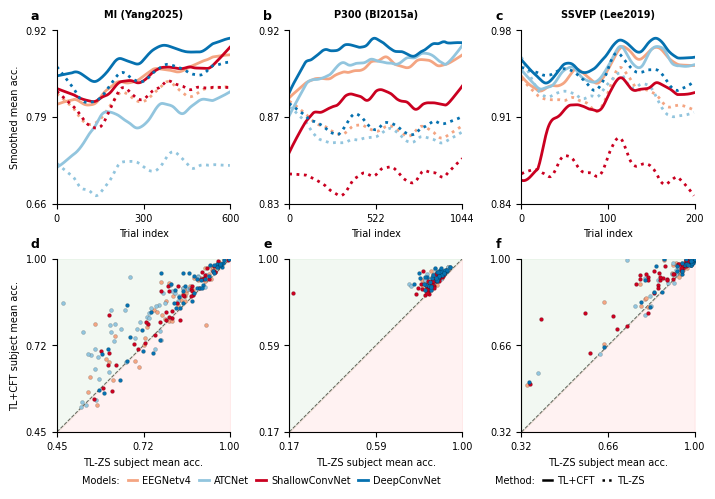

In [ ]:
# --- Figure Layout and Style Configuration (from fig_2.py) ---
MAX_TOTAL_WIDTH_MM = 180.0
MARGIN_LEFT_CM = 1.4
MARGIN_RIGHT_CM = 0.4
MARGIN_TOP_CM = 0.8
MARGIN_BOTTOM_CM = 1.7
SPACING_HORIZONTAL_CM = 1.5
SPACING_VERTICAL_CM = 1.4
NUM_COLS = 3
NUM_ROWS = 2

# Calculate figure and panel dimensions
total_width_cm = MAX_TOTAL_WIDTH_MM / 10.0
effective_width_cm = total_width_cm - MARGIN_LEFT_CM - MARGIN_RIGHT_CM
panel_width_cm = (effective_width_cm - (NUM_COLS - 1) * SPACING_HORIZONTAL_CM) / NUM_COLS
panel_height_cm = panel_width_cm  # Keep panels square

effective_height_cm = NUM_ROWS * panel_height_cm + (NUM_ROWS - 1) * SPACING_VERTICAL_CM
total_height_cm = effective_height_cm + MARGIN_BOTTOM_CM + MARGIN_TOP_CM

# Convert to inches for matplotlib
total_width_inches = total_width_cm / 2.54
total_height_inches = total_height_cm / 2.54

# --- Create the figure ---
fig, axes = plt.subplots(NUM_ROWS, NUM_COLS, 
                         figsize=(total_width_inches, total_height_inches),
                         squeeze=False)

panel_labels = list(string.ascii_lowercase)

# Plot time series (top row)
for col, dataset in enumerate(DATASETS_ORDER):
    ax = axes[0, col]
    ax.text(-0.15, 1.12, panel_labels[col], transform=ax.transAxes, fontsize=FONTSIZE + 2, fontweight='bold', va='top', ha='left')
    ax.set_title(DATASET_LABELS[dataset], fontsize=FONTSIZE, weight='bold', y=1.025)
    plot_time_series(ax, dataset, 
                     cutoff=DATASET_TRIAL_CUTOFFS[dataset],
                     show_xlabel=True, 
                     show_ylabel=(col==0),
                     show_legend=False)

# Plot scatter plots (bottom row)
for col, dataset in enumerate(DATASETS_ORDER):
    ax = axes[1, col]
    ax.text(-0.15, 1.12, panel_labels[col + NUM_COLS], transform=ax.transAxes, fontsize=FONTSIZE + 2, fontweight='bold', va='top', ha='left')
    plot_scatter(ax, dataset,
                 show_xlabel=True,
                 show_ylabel=(col==0),
                 show_legend=False)

# --- Add legends at the bottom (from fig_2.py) ---
from matplotlib.lines import Line2D
model_elements = [Line2D([0], [0], color=color, label=model, linewidth=2) for model, color in MODEL_COLORS.items()]
method_elements = [
    Line2D([0], [0], color='black', lw=1.8, label='TL+CFT', linestyle='-'),
    Line2D([0], [0], color='black', lw=1.8, label='TL-ZS', linestyle='dotted')
]
models_title = mpatches.Patch(color='none', label='Models:')
spacer = mpatches.Patch(color='none', label='   ')
method_title = mpatches.Patch(color='none', label='Method:')
all_handles = [models_title] + model_elements + [spacer] + [method_title] + method_elements

fig.legend(handles=all_handles, loc='lower center', bbox_to_anchor=(0.5, 0.01), 
           ncol=len(all_handles), frameon=False, fontsize=FONTSIZE, 
           handletextpad=0.5, columnspacing=0.8, handlelength=1.0)

# --- Adjust layout (from fig_2.py) ---
left_norm = MARGIN_LEFT_CM / total_width_cm
right_norm = 1 - (MARGIN_RIGHT_CM / total_width_cm)
bottom_norm = MARGIN_BOTTOM_CM / total_height_cm
top_norm = 1 - (MARGIN_TOP_CM / total_height_cm)
wspace_val = SPACING_HORIZONTAL_CM / panel_width_cm if panel_width_cm > 0 else 0.1
hspace_val = SPACING_VERTICAL_CM / panel_height_cm if panel_height_cm > 0 else 0.1

fig.subplots_adjust(left=left_norm, right=right_norm, bottom=bottom_norm, top=top_norm, wspace=wspace_val, hspace=hspace_val)

# Save and show figure
plt.savefig('figure2_reproduction.pdf', dpi=300)
plt.show()

In [6]:
# Display summary statistics
print("Data Summary:")
print("=" * 50)

print("\nTime Series Data Points per Dataset:")
for dataset in DATASETS_ORDER:
    count = len(time_series_df[time_series_df['dataset'] == dataset])
    print(f"  {DATASET_LABELS[dataset]}: {count} data points")

print("\nScatter Plot Subjects per Dataset:")
for dataset in DATASETS_ORDER:
    dataset_data = scatter_df[scatter_df['dataset'] == dataset]
    # Count subjects with both TL-ZS and TL+CFT data
    complete_subjects = dataset_data.dropna(subset=['TL-ZS', 'TL+CFT'])
    n_subjects = len(complete_subjects)
    print(f"  {DATASET_LABELS[dataset]}: {n_subjects} subjects")

print("\nMean Performance Comparison:")
for dataset in DATASETS_ORDER:
    dataset_data = scatter_df[scatter_df['dataset'] == dataset].dropna(subset=['TL-ZS', 'TL+CFT'])
    if not dataset_data.empty:
        mean_zs = dataset_data['TL-ZS'].mean()
        mean_cft = dataset_data['TL+CFT'].mean()
        improvement = mean_cft - mean_zs
        print(f"  {DATASET_LABELS[dataset]}:")
        print(f"    TL-ZS: {mean_zs:.3f}")
        print(f"    TL+CFT: {mean_cft:.3f}")
        print(f"    Improvement: {improvement:+.3f}")

Data Summary:

Time Series Data Points per Dataset:
  MI (Yang2025): 4800 data points
  P300 (BI2015a): 8352 data points
  SSVEP (Lee2019): 1600 data points

Scatter Plot Subjects per Dataset:
  MI (Yang2025): 200 subjects
  P300 (BI2015a): 170 subjects
  SSVEP (Lee2019): 213 subjects

Mean Performance Comparison:
  MI (Yang2025):
    TL-ZS: 0.797
    TL+CFT: 0.841
    Improvement: +0.044
  P300 (BI2015a):
    TL-ZS: 0.861
    TL+CFT: 0.902
    Improvement: +0.041
  SSVEP (Lee2019):
    TL-ZS: 0.920
    TL+CFT: 0.947
    Improvement: +0.026
